# Phân cụm K-Means

K-Means là thuật toán phân cụm (unsupervised learning) nhằm chia dữ liệu thành `k` cụm sao cho các điểm trong cùng cụm giống nhau và khác với cụm khác. Mục tiêu là **tối thiểu hoá tổng bình phương khoảng cách trong cụm** (Within-Cluster Sum of Squares - WCSS).

Ý tưởng chính:
- Khởi tạo `k` tâm cụm (centroids), thường dùng `k-means++` để ổn định.
- Lặp: (1) gán mỗi điểm vào cụm có tâm gần nhất; (2) cập nhật tâm cụm bằng trung bình các điểm trong cụm.
- Dừng khi tâm cụm hội tụ hoặc đạt `max_iter`.

Các tham số quan trọng:
- `n_clusters`: số cụm cần tìm.
- `init`: cách khởi tạo tâm (`k-means++` khuyến nghị).
- `n_init`: số lần chạy với khởi tạo khác nhau để chọn lời giải tốt nhất.
- `max_iter`: số vòng lặp tối đa.
- `random_state`: cố định ngẫu nhiên để tái lập kết quả.


Đánh giá kết quả:
- Nếu nhãn thật: so sánh bằng `Adjusted Rand Index (ARI)`, `Normalized Mutual Information (NMI)`, và có thể ánh xạ cụm → nhãn theo đa số để tính độ chính xác.
- Nếu không có nhãn: dùng `Silhouette Score` để đo mức phân tách cụm.

Dưới đây là 2 ví dụ dùng dataset :
1) Breast Cancer Wisconsin (có nhãn Malignant/Benign) – so sánh cụm với nhãn thật.
2) Diabetes (mục tiêu liên tục) – rời rạc hoá thành 3 mức rủi ro để đánh giá clustering.


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


## Ví dụ 1: Breast Cancer Wisconsin (có nhãn)
Dataset gồm các đặc trưng đo lường tế bào và nhãn nhị phân: `Malignant (ác tính)` và `Benign (lành tính)`. Ta dùng K-Means với `k=2`, chuẩn hoá đặc trưng, và đánh giá bằng ARI, NMI.


Kích thước dữ liệu (Breast Cancer): (569, 30)
Bảng chéo (cluster vs true):
true       0    1
cluster          
0         36  339
1        176   18
ARI: 0.654 | NMI: 0.532 | Accuracy (mapping): 0.905 | Silhouette: 0.343


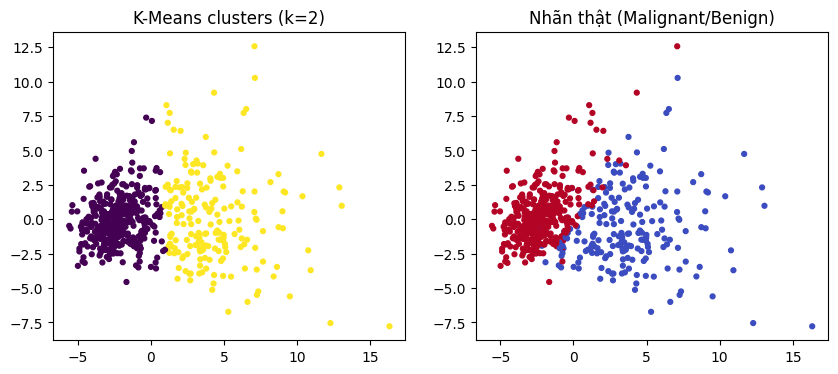

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# Tải dữ liệu và chuẩn hoá
bc = load_breast_cancer()
X_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc = pd.Series(bc.target, name='label')  # 0 = malignant, 1 = benign
print('Kích thước dữ liệu (Breast Cancer):', X_bc.shape)

scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)

# Chạy K-Means với 2 cụm
kmeans_bc = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
clusters_bc = kmeans_bc.fit_predict(X_bc_scaled)

# Bảng so sánh cụm với nhãn thật
ct_bc = pd.crosstab(pd.Series(clusters_bc, name='cluster'), y_bc, rownames=['cluster'], colnames=['true'])
print('Bảng chéo (cluster vs true):')
print(ct_bc)

# Ánh xạ cụm sang nhãn theo đa số để tính độ chính xác
mapping_bc = {}
for c in np.unique(clusters_bc):
    idx = clusters_bc == c
    majority = y_bc[idx].mode()
    mapping_bc[c] = int(majority.iloc[0]) if len(majority) > 0 else 0
pred_bc = pd.Series(clusters_bc).map(mapping_bc).values
acc_bc = (pred_bc == y_bc.values).mean()

# Các chỉ số đánh giá
ari_bc = adjusted_rand_score(y_bc, clusters_bc)
nmi_bc = normalized_mutual_info_score(y_bc, clusters_bc)
sil_bc = silhouette_score(X_bc_scaled, clusters_bc)
print(f'ARI: {ari_bc:.3f} | NMI: {nmi_bc:.3f} | Accuracy (mapping): {acc_bc:.3f} | Silhouette: {sil_bc:.3f}')


pca = PCA(n_components=2)
X_bc_2d = pca.fit_transform(X_bc_scaled)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_bc_2d[:,0], X_bc_2d[:,1], c=clusters_bc, cmap='viridis', s=12)
axes[0].set_title('K-Means clusters (k=2)')
axes[1].scatter(X_bc_2d[:,0], X_bc_2d[:,1], c=y_bc, cmap='coolwarm', s=12)
axes[1].set_title('Nhãn thật (Malignant/Benign)')
plt.show()



### Nhận xét (Breast Cancer)
- Chuẩn hoá đặc trưng giúp K-Means ổn định hơn.
- ARI/NMI thường khá tốt vì dữ liệu có cấu trúc hai cụm rõ ràng.
- Ánh xạ đa số cho thấy độ chính xác phân cụm so với nhãn thật, nhưng đây không phải mô hình phân loại.
- Silhouette > 0 cho thấy phân tách cụm tương đối; càng cao càng tốt.
- K-Means giả định cụm có dạng "hình cầu" và kích thước tương đối giống nhau; nếu dữ liệu không thoả, chất lượng phân cụm giảm.


## Ví dụ 2: Diabetes (mục tiêu liên tục) – rời rạc hoá 3 mức rủi ro
Target trong dataset Diabetes là số thực (tiến triển bệnh). Để đánh giá clustering, ta rời rạc hoá thành 3 mức rủi ro theo các **phân vị** 33% và 66%: "Thấp", "Trung bình", "Cao". Sau đó chạy K-Means với `k=3` và so sánh bằng ARI/NMI.


Kích thước dữ liệu (Diabetes): (442, 10)
Bảng chéo (cluster vs risk):
risk      0   1   2
cluster            
0        12  42  71
1        46  53  60
2        89  52  17
ARI: 0.098 | NMI: 0.105 | Accuracy (mapping): 0.498 | Silhouette: 0.153


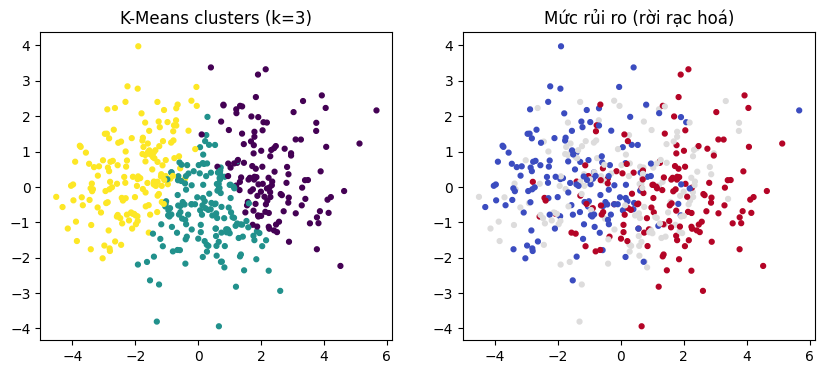

In [15]:
# Tải dữ liệu Diabetes và chuẩn hoá
diab = load_diabetes()
X_diab = pd.DataFrame(diab.data, columns=diab.feature_names)
y_diab_cont = pd.Series(diab.target, name='target')
print('Kích thước dữ liệu (Diabetes):', X_diab.shape)

# Rời rạc hoá thành 3 mức rủi ro theo phân vị 33% và 66%
q_low, q_high = np.quantile(y_diab_cont, [1/3, 2/3])
bins = [-np.inf, q_low, q_high, np.inf]
y_diab_cat = np.digitize(y_diab_cont, bins) - 1  # 0=Thấp, 1=Trung bình, 2=Cao
labels_diab = np.array(['Thấp', 'Trung bình', 'Cao'])

scaler_diab = StandardScaler()
X_diab_scaled = scaler_diab.fit_transform(X_diab)

# Chạy K-Means với 3 cụm
kmeans_diab = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
clusters_diab = kmeans_diab.fit_predict(X_diab_scaled)

# Bảng chéo
ct_diab = pd.crosstab(pd.Series(clusters_diab, name='cluster'), pd.Series(y_diab_cat, name='risk'))
print('Bảng chéo (cluster vs risk):')
print(ct_diab)

# Ánh xạ cụm sang mức rủi ro theo đa số
mapping_diab = {}
for c in np.unique(clusters_diab):
    idx = clusters_diab == c
    majority = pd.Series(y_diab_cat)[idx].mode()
    mapping_diab[c] = int(majority.iloc[0]) if len(majority) > 0 else 0
pred_diab = pd.Series(clusters_diab).map(mapping_diab).values
acc_diab = (pred_diab == y_diab_cat).mean()

# Các chỉ số đánh giá
ari_diab = adjusted_rand_score(y_diab_cat, clusters_diab)
nmi_diab = normalized_mutual_info_score(y_diab_cat, clusters_diab)
sil_diab = silhouette_score(X_diab_scaled, clusters_diab)
print(f'ARI: {ari_diab:.3f} | NMI: {nmi_diab:.3f} | Accuracy (mapping): {acc_diab:.3f} | Silhouette: {sil_diab:.3f}')


import matplotlib.pyplot as plt
pca2 = PCA(n_components=2)
X_diab_2d = pca2.fit_transform(X_diab_scaled)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_diab_2d[:,0], X_diab_2d[:,1], c=clusters_diab, cmap='viridis', s=12)
axes[0].set_title('K-Means clusters (k=3)')
axes[1].scatter(X_diab_2d[:,0], X_diab_2d[:,1], c=y_diab_cat, cmap='coolwarm', s=12)
axes[1].set_title('Mức rủi ro (rời rạc hoá)')
plt.show()


### Nhận xét (Diabetes)
- Việc rời rạc hoá theo phân vị là **giả định** để tiện đánh giá; ranh giới có thể thay đổi kết quả.
- Vì mục tiêu gốc là liên tục, phân cụm không nhất thiết khớp hoàn toàn với 3 mức rủi ro đặt ra.
- ARI/NMI cho biết mức độ tương quan giữa cụm và mức rủi ro; Silhouette đo chất lượng phân tách cụm.
- Chuẩn hoá vẫn rất quan trọng; K-Means nhạy với thang đo, outliers.


## Kết luận
- K-Means đơn giản, nhanh, phù hợp khi giả định cụm dạng gần cầu và dữ liệu đã chuẩn hoá.
- Khi có nhãn, có thể đánh giá thêm bằng ARI/NMI; khi không có nhãn, dùng Silhouette/Calinski-Harabasz/Davies-Bouldin.
- Việc chọn `k` rất quan trọng (Elbow, Silhouette, knowledge domain).
- Đối với mục tiêu liên tục (như Diabetes), rời rạc hoá chỉ là cách phụ trợ để **đánh giá** clustering, không phải ground truth tuyệt đối.
